# Customer Purchase Propensity - Data Cleaning and Feature Engineering Pipeline

# ----------------------------------------------------------

# Data Import and Understanding 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("C:/Users/MR_MAHESH/Data Science/Dataset/practical_datapreprocessing/customers - customers.csv.csv")

print("Customers Dataset:")
display(customers.head())

print("\nShape:")
print(customers.shape)

Customers Dataset:


,customer_id,name,age,gender,city,income
0,101,Aarav,24,Male,Mumbai,45000
1,102,Diya,30,Female,Delhi,55000
2,103,Kabir,27,Male,Bangalore,48000
3,104,Meera,35,Female,Ahmedabad,60000
4,105,Vivaan,40,Male,Pune,75000



Shape:
(8, 6)


In [3]:
transactions = pd.read_json("C:/Users/MR_MAHESH/Data Science/Dataset/practical_datapreprocessing/transactions.json")

print("Transactions Dataset:")
display(transactions.head())

print("\nShape:")
print(transactions.shape)

Transactions Dataset:


,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07



Shape:
(8, 6)


In [4]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="2005",
    database="datapro")
print("MySQL database connected successfully!")

products = pd.read_sql(
    "SELECT * FROM products",connection)

print("Products data loaded successfully!")

display(products.head())

MySQL database connected successfully!
Products data loaded successfully!


C:\Users\MR_MAHESH\AppData\Local\Temp\ipykernel_10600\2139585263.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql(


,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,50
1,P002,Bluetooth Speaker,Audio,699,40
2,P003,Smart Watch,Wearable,1299,25
3,P004,Keyboard,Computer,899,60
4,P005,Headphones,Audio,1999,30


In [6]:
import requests

url = "https://dummyjson.com/users"

response = requests.get(url)

api_data = response.json()

api_users = pd.DataFrame(api_data["users"])

display(api_users.head())

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


In [7]:
print("Customers Shape:", customers.shape)
print("Transactions Shape:", transactions.shape)
print("Products Shape:", products.shape)
print("API Users Shape:", api_users.shape)

Customers Shape: (8, 6)
Transactions Shape: (8, 6)
Products Shape: (6, 5)
API Users Shape: (30, 28)


In [8]:
df = pd.merge(customers,transactions,on="customer_id",how="left")
print(df.shape)
display(df.head())

(8, 11)


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05


In [9]:
df = pd.merge(df,products,on="product_id",how="left")
print(df.shape)
display(df.head())

(8, 15)


,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


In [10]:
df.head()

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     8 non-null      int64         
 1   name            8 non-null      object        
 2   age             8 non-null      int64         
 3   gender          8 non-null      object        
 4   city            8 non-null      object        
 5   income          8 non-null      int64         
 6   transaction_id  8 non-null      object        
 7   product_id      8 non-null      object        
 8   amount          8 non-null      int64         
 9   payment_mode    8 non-null      object        
 10  date            8 non-null      datetime64[ns]
 11  product_name    8 non-null      object        
 12  category        8 non-null      object        
 13  price           8 non-null      int64         
 14  stock           8 non-null      int64         
dtypes: datetim

In [12]:
df.describe(include="all")

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
count,8.00000,8,8.000000,8,8,8.000000,8,8,8.000000,8,8,8,8,8.000000,8.000000
unique,NaN,8,NaN,2,8,NaN,8,6,NaN,4,NaN,6,5,NaN,NaN
top,NaN,Aarav,NaN,Male,Mumbai,NaN,T001,P001,NaN,UPI,NaN,Earphones,Electronics,NaN,NaN
freq,NaN,1,NaN,4,1,NaN,1,2,NaN,3,NaN,2,2,NaN,NaN
mean,104.50000,NaN,30.000000,NaN,NaN,54125.000000,NaN,NaN,1249.000000,NaN,2025-10-05 15:00:00,NaN,NaN,1224.000000,37.500000
min,101.00000,NaN,22.000000,NaN,NaN,42000.000000,NaN,NaN,499.000000,NaN,2025-10-01 00:00:00,NaN,NaN,499.000000,20.000000
25%,102.75000,NaN,26.250000,NaN,NaN,47250.000000,NaN,NaN,649.000000,NaN,2025-10-02 18:00:00,NaN,NaN,649.000000,25.000000
50%,104.50000,NaN,29.500000,NaN,NaN,52500.000000,NaN,NaN,1099.000000,NaN,2025-10-06 00:00:00,NaN,NaN,1099.000000,35.000000
75%,106.25000,NaN,33.500000,NaN,NaN,58500.000000,NaN,NaN,1624.000000,NaN,2025-10-08 06:00:00,NaN,NaN,1474.000000,50.000000
max,108.00000,NaN,40.000000,NaN,NaN,75000.000000,NaN,NaN,2599.000000,NaN,2025-10-10 00:00:00,NaN,NaN,2599.000000,60.000000


In [14]:
missing_data = pd.DataFrame({
    "Missing Value" : df.isnull().sum(),
    "Missing Percentage " : (df.isnull().sum() / len(df)) * 100 })
display(missing_data)

,Missing Value,Missing Percentage
customer_id,0,0.0
name,0,0.0
age,0,0.0
gender,0,0.0
city,0,0.0
income,0,0.0
transaction_id,0,0.0
product_id,0,0.0
amount,0,0.0
payment_mode,0,0.0


# Exploratory Data Analysis (EDA) 

Univariate Analysis

In [15]:
# Visualize numerical features using histograms and identify skewness

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)

['customer_id', 'age', 'income', 'amount', 'price', 'stock']


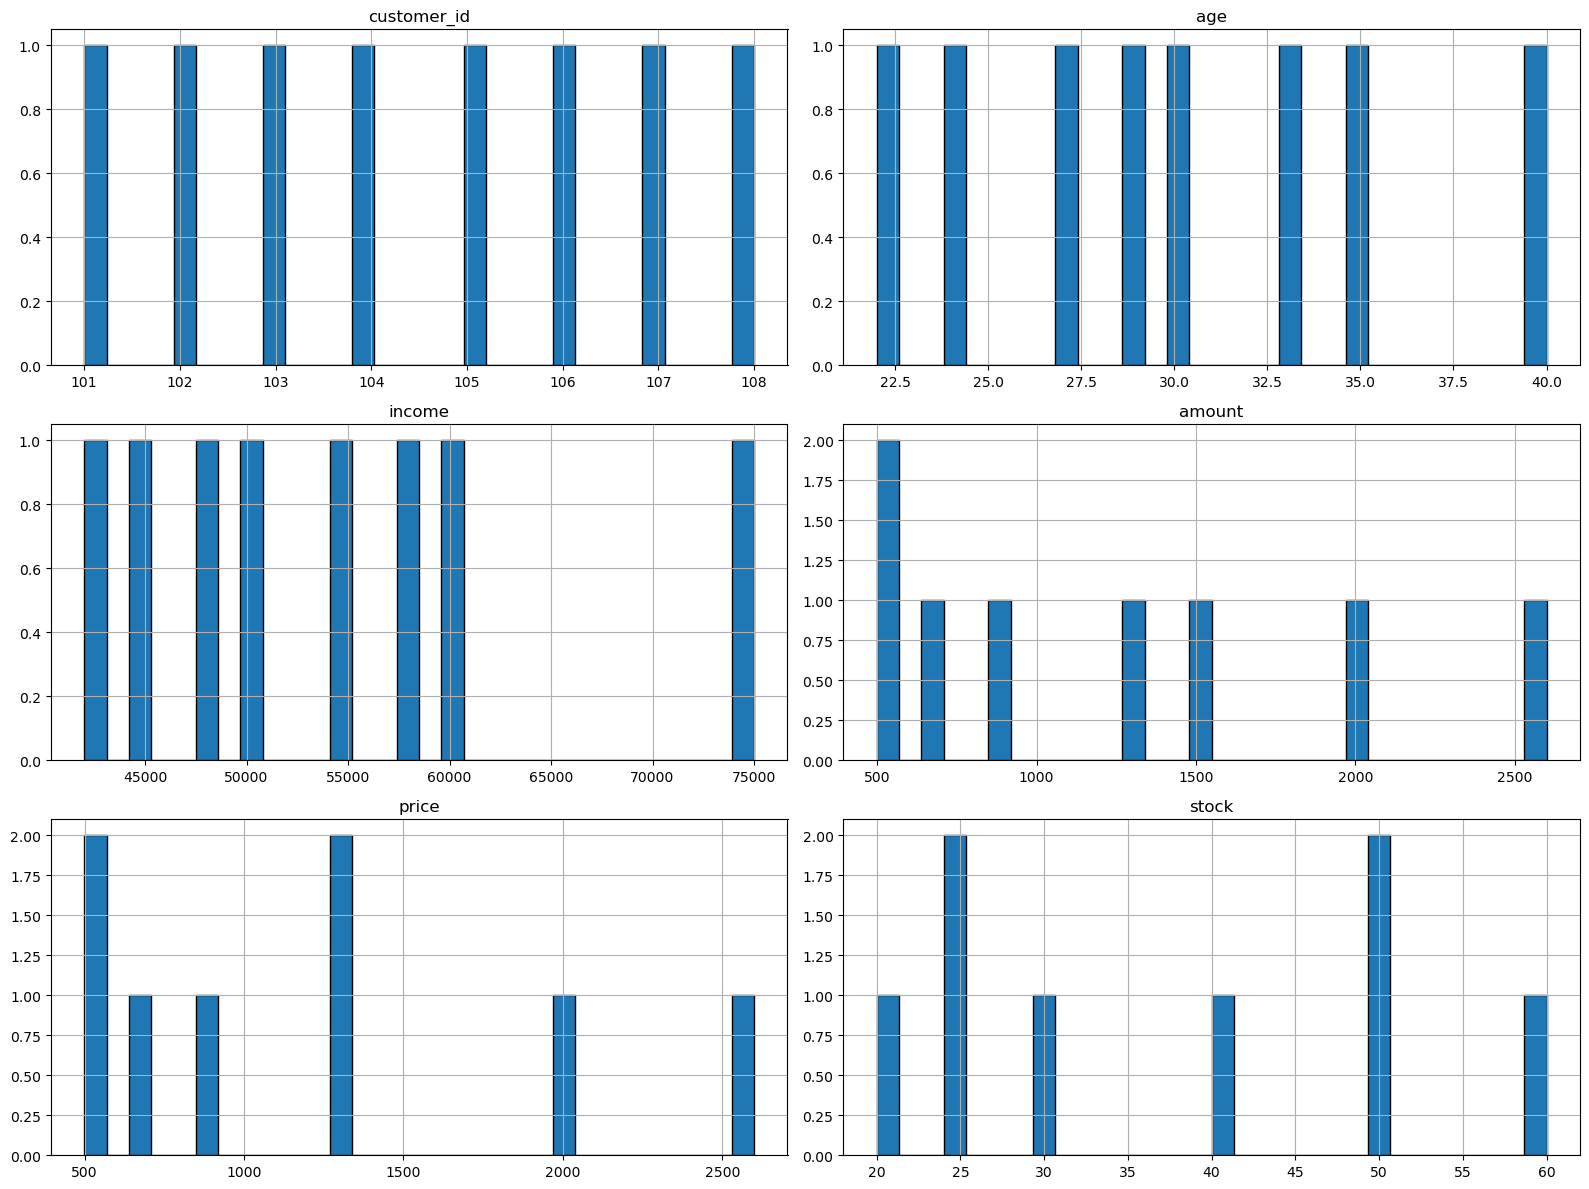

In [16]:
df[numeric_cols].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor="black")
plt.tight_layout()
plt.show()

In [17]:
# Identify Skewed Variables
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

income         1.073956
price          0.960237
amount         0.813569
age            0.366520
stock          0.341565
customer_id    0.000000
dtype: float64


In [18]:
skewed_variables = skewness[abs(skewness) > 1]
print("Highly Skewed Variables:")
print(skewed_variables)

Highly Skewed Variables:
income    1.073956
dtype: float64


In [19]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df,
    title="Customer Purchase Data Profiling Report",
    explorative=True)
profile.to_file("customer_profile_report.html")
print("Profiling report created successfully!")

C:\Users\MR_MAHESH\AppData\Local\Temp\ipykernel_10600\2300104878.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 354.80it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report created successfully!


Bivariate Analysis 

In [26]:
# Correlate numerical features with the target column (purchased = 1 or 0)

if "purchased" in df.columns:
    correlation = df[numeric_cols].corr()["purchased"].sort_values(ascending=False)
    print(correlation)

In [27]:
# Income vs Purchase

if "income" in df.columns and "purchased" in df.columns:
    print(df.groupby("purchased")["income"].mean())


Multivariate Analysis 

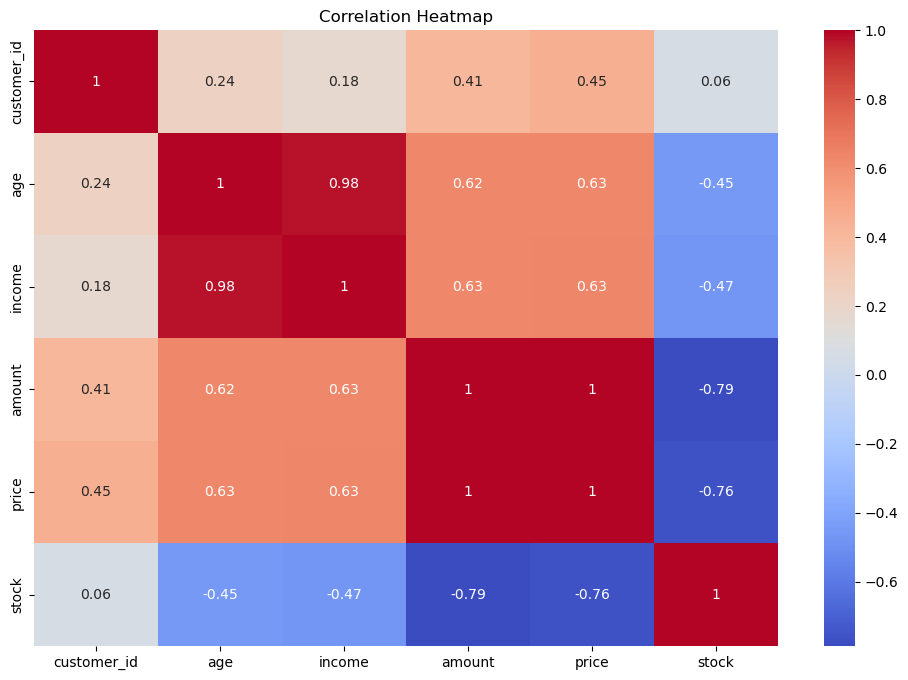

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(),cmap="coolwarm",annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
selected_cols = numeric_cols[:5]
if "purchased" in df.columns:
    sns.pairplot(df[selected_cols + ["purchased"]],hue="purchased")

# Handling Missing Data 

In [31]:
df_clean = df.copy()

In [33]:
from sklearn.impute import (SimpleImputer,
    KNNImputer,
    MissingIndicator)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [32]:
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

cat_cols = df_clean.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['customer_id', 'age', 'income', 'amount', 'price', 'stock']

Categorical Columns:
['name', 'gender', 'city', 'transaction_id', 'product_id', 'payment_mode', 'product_name', 'category']


In [34]:
simple_num_imputer = SimpleImputer(strategy="median")
df_clean[num_cols] = simple_num_imputer.fit_transform(df_clean[num_cols])

In [35]:
simple_cat_imputer = SimpleImputer(strategy="most_frequent")
if len(cat_cols) > 0:
    df_clean[cat_cols] = simple_cat_imputer.fit_transform(df_clean[cat_cols])

In [36]:
for col in num_cols:
    df_clean[col + "_missing"] = df[col].isnull().astype(int)
print("Missing indicator columns created!")

Missing indicator columns created!


In [37]:
for col in num_cols:
    missing_indexes = df_clean[df_clean[col].isnull()].index
    if len(missing_indexes) > 0:
        random_sample = df_clean[col].dropna().sample(
            len(missing_indexes),
            replace=True,
            random_state=42)  
        random_sample.index = missing_indexesdf_clean.loc[missing_indexes,col] = random_sample

In [38]:
knn_df = df[num_cols].copy()
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputed = knn_imputer.fit_transform(knn_df)
knn_imputed_df = pd.DataFrame(knn_imputed,columns=num_cols)
display(knn_imputed_df.head())

,customer_id,age,income,amount,price,stock
0,101.0,24.0,45000.0,499.0,499.0,50.0
1,102.0,30.0,55000.0,1499.0,1299.0,25.0
2,103.0,27.0,48000.0,1299.0,1299.0,25.0
3,104.0,35.0,60000.0,699.0,699.0,40.0
4,105.0,40.0,75000.0,1999.0,1999.0,30.0


In [39]:
mice_imputer = IterativeImputer(random_state=42)
mice_imputed = mice_imputer.fit_transform(df[num_cols])
mice_imputed_df = pd.DataFrame(mice_imputed,columns=num_cols)
display(mice_imputed_df.head())

,customer_id,age,income,amount,price,stock
0,101.0,24.0,45000.0,499.0,499.0,50.0
1,102.0,30.0,55000.0,1499.0,1299.0,25.0
2,103.0,27.0,48000.0,1299.0,1299.0,25.0
3,104.0,35.0,60000.0,699.0,699.0,40.0
4,105.0,40.0,75000.0,1999.0,1999.0,30.0


In [40]:
complete_case_df = df.dropna()
print("Original Shape:", df.shape)
print("Complete Case Shape:",complete_case_df.shape)

Original Shape: (8, 15)
Complete Case Shape: (8, 15)


# Outlier Detection & Handling 

In [42]:
# Z Score Method
from scipy.stats import zscore

z_scores = np.abs(zscore(df_clean[num_cols],nan_policy="omit"))
outliers_zscore = (z_scores > 3).sum(axis=0)
print("Outliers using Z-Score:")
print(outliers_zscore)

Outliers using Z-Score:
[0 0 0 0 0 0]


In [43]:
df_zscore = df_clean.copy()
z_scores = np.abs(zscore(df_zscore[num_cols]))
mask = (z_scores < 3).all(axis=1)
df_zscore = df_zscore[mask]
print("Shape after Z-score:", df_zscore.shape)

Shape after Z-score: (8, 21)


In [44]:
# IQR Method

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25) 
    Q3 = df_clean[col].quantile(0.75) 
    IQR = Q3 - Q1 
    lower = Q1 - 1.5 * IQR 
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper) ] 
    print(col,"Outliers:",len(outliers))

customer_id Outliers: 0
age Outliers: 0
income Outliers: 0
amount Outliers: 0
price Outliers: 0
stock Outliers: 0


In [45]:
# Percentile Method

for col in num_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99) 
    print(col,"Lower:",lower,
        "Upper:",upper)

customer_id Lower: 101.07 Upper: 107.93
age Lower: 22.14 Upper: 39.65
income Lower: 42210.0 Upper: 73950.0
amount Lower: 499.0 Upper: 2557.0
price Lower: 499.0 Upper: 2557.0
stock Lower: 20.35 Upper: 59.3


In [46]:
# Winsorization

for col in num_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower,upper)
print("Outliers capped successfully!")

Outliers capped successfully!


# Handling Mixed & Date/Time Variables 

In [47]:
date_columns = ["signup_date","last_purchase_date"]
for col in date_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col],errors="coerce")

In [48]:
# Days Since Last Purchase

if "last_purchase_date" in df_clean.columns:
    reference_date = pd.Timestamp.today()
    df_clean["days_since_last_purchase"] = (reference_date -df_clean["last_purchase_date"]).dt.days

In [49]:
# Days Since Signup

if "signup_date" in df_clean.columns:
    df_clean["days_since_signup"] = (pd.Timestamp.today() -df_clean["signup_date"]
    ).dt.days

In [50]:
# Handle Mixed Customer ID

if "customer_id" in df_clean.columns:
    df_clean["customer_id_numeric"] = (df_clean["customer_id"].astype(str).str.extract(r"(\d+)").astype(float))

# Encoding Categorical Data

In [51]:
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder)

label_encoder = LabelEncoder()
label_encoded_cols = []
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col + "_label"] = label_encoder.fit_transform(df_clean[col].astype(str))
        label_encoded_cols.append(col + "_label")
print(label_encoded_cols)

['name_label', 'gender_label', 'city_label', 'transaction_id_label', 'product_id_label', 'payment_mode_label', 'product_name_label', 'category_label']


In [52]:
# One Hot Encoding

df_encoded = pd.get_dummies(df_clean,columns=cat_cols,drop_first=True)
print(df_encoded.shape)

(8, 61)


In [53]:
# Ordinal Encoding

if "education" in df_clean.columns:
    education_order = [["High School","Bachelor","Master","PhD"]]
    ordinal_encoder = OrdinalEncoder(categories=education_order) 
    df_clean["education_encoded"] = (ordinal_encoder.fit_transform(df_clean[["education"]]))

In [54]:
# Income Binning
if "income" in df_clean.columns: df_clean["income_group"] = pd.qcut(df_clean["income"],q=4,
        labels=["Low","Medium","High","Very High"],duplicates="drop")

# Feature Scaling 

In [62]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
     Normalizer)

In [56]:
scale_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
print(scale_cols)

['customer_id', 'age', 'income', 'amount', 'price', 'stock', 'customer_id_missing', 'age_missing', 'income_missing', 'amount_missing', 'price_missing', 'stock_missing', 'customer_id_numeric', 'name_label', 'gender_label', 'city_label', 'transaction_id_label', 'product_id_label', 'payment_mode_label', 'product_name_label', 'category_label']


In [57]:
# StandardScaler

standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(df_clean[scale_cols])
standard_scaled_df = pd.DataFrame(standard_scaled,columns=scale_cols)
display(standard_scaled_df.head())

,customer_id,age,income,amount,price,stock,customer_id_missing,age_missing,income_missing,amount_missing,...,stock_missing,customer_id_numeric,name_label,gender_label,city_label,transaction_id_label,product_id_label,payment_mode_label,product_name_label,category_label
0,-1.514570,-1.102437,-0.948815,-1.068278,-1.041443,0.929534,0.0,0.0,0.0,0.0,...,0.0,-1.593760,-1.527525,1.0,0.654654,-1.527525,-1.256676,1.128576,-0.903562,0.000000
1,-1.103914,0.004844,0.103086,0.366134,0.116118,-0.923050,0.0,0.0,0.0,0.0,...,0.0,-1.121535,-0.654654,-1.0,-0.218218,1.091089,-0.073922,-0.512989,1.320591,1.333333
2,-0.662348,-0.548796,-0.633244,0.079251,0.116118,-0.923050,0.0,0.0,0.0,0.0,...,0.0,-0.649309,0.218218,1.0,-1.091089,-1.091089,-0.073922,-0.512989,1.320591,1.333333
3,-0.220783,0.927579,0.629037,-0.781396,-0.752053,0.188500,0.0,0.0,0.0,0.0,...,0.0,-0.177084,0.654654,-1.0,-1.527525,-0.654654,-0.665299,0.307794,-1.459601,-1.333333
4,0.220783,1.785721,2.096438,1.083340,1.128984,-0.552533,0.0,0.0,0.0,0.0,...,0.0,0.295141,1.527525,1.0,1.091089,-0.218218,1.108832,1.128576,-0.347524,-1.333333


In [58]:
# MinMaxScaler

minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(df_clean[scale_cols])
minmax_scaled_df = pd.DataFrame(minmax_scaled,columns=scale_cols)
display(minmax_scaled_df.head())

,customer_id,age,income,amount,price,stock,customer_id_missing,age_missing,income_missing,amount_missing,...,stock_missing,customer_id_numeric,name_label,gender_label,city_label,transaction_id_label,product_id_label,payment_mode_label,product_name_label,category_label
0,0.000000,0.106225,0.087902,0.000000,0.000000,0.761232,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,1.0,0.714286,0.000000,0.0,1.000000,0.2,0.5
1,0.135569,0.448886,0.402962,0.485909,0.388727,0.119384,0.0,0.0,0.0,0.0,...,0.0,0.166667,0.285714,0.0,0.428571,0.857143,0.4,0.333333,1.0,1.0
2,0.281341,0.277556,0.182420,0.388727,0.388727,0.119384,0.0,0.0,0.0,0.0,...,0.0,0.333333,0.571429,1.0,0.142857,0.142857,0.4,0.333333,1.0,1.0
3,0.427114,0.734437,0.560491,0.097182,0.097182,0.504493,0.0,0.0,0.0,0.0,...,0.0,0.500000,0.714286,0.0,0.000000,0.285714,0.2,0.666667,0.0,0.0
4,0.572886,1.000000,1.000000,0.728863,0.728863,0.247754,0.0,0.0,0.0,0.0,...,0.0,0.666667,1.000000,1.0,0.857143,0.428571,0.8,1.000000,0.4,0.0


In [59]:
# MaxAbsScaler

maxabs_scaler = MaxAbsScaler()
maxabs_scaled = maxabs_scaler.fit_transform(df_clean[scale_cols])
display(pd.DataFrame(maxabs_scaled,columns=scale_cols).head())

,customer_id,age,income,amount,price,stock,customer_id_missing,age_missing,income_missing,amount_missing,...,stock_missing,customer_id_numeric,name_label,gender_label,city_label,transaction_id_label,product_id_label,payment_mode_label,product_name_label,category_label
0,0.936440,0.605296,0.608519,0.195151,0.195151,0.843170,0.0,0.0,0.0,0.0,...,0.0,0.943925,0.000000,1.0,0.714286,0.000000,0.0,1.000000,0.2,0.5
1,0.945057,0.756620,0.743746,0.586234,0.508017,0.421585,0.0,0.0,0.0,0.0,...,0.0,0.953271,0.285714,0.0,0.428571,0.857143,0.4,0.333333,1.0,1.0
2,0.954322,0.680958,0.649087,0.508017,0.508017,0.421585,0.0,0.0,0.0,0.0,...,0.0,0.962617,0.571429,1.0,0.142857,0.142857,0.4,0.333333,1.0,1.0
3,0.963588,0.882724,0.811359,0.273367,0.273367,0.674536,0.0,0.0,0.0,0.0,...,0.0,0.971963,0.714286,0.0,0.000000,0.285714,0.2,0.666667,0.0,0.0
4,0.972853,1.000000,1.000000,0.781776,0.781776,0.505902,0.0,0.0,0.0,0.0,...,0.0,0.981308,1.000000,1.0,0.857143,0.428571,0.8,1.000000,0.4,0.0


In [60]:
# RobustScaler
robust_scaler = RobustScaler()
robust_scaled = robust_scaler.fit_transform(df_clean[scale_cols])
display(pd.DataFrame(robust_scaled,columns=scale_cols).head())

,customer_id,age,income,amount,price,stock,customer_id_missing,age_missing,income_missing,amount_missing,...,stock_missing,customer_id_numeric,name_label,gender_label,city_label,transaction_id_label,product_id_label,payment_mode_label,product_name_label,category_label
0,-0.980000,-0.758621,-0.666667,-0.615385,-0.727273,0.6,0.0,0.0,0.0,0.0,...,0.0,-1.000000,-1.000000,0.5,0.428571,-1.000000,-0.8,0.666667,-0.461538,0.0
1,-0.714286,0.068966,0.222222,0.410256,0.242424,-0.4,0.0,0.0,0.0,0.0,...,0.0,-0.714286,-0.428571,-0.5,-0.142857,0.714286,0.0,-0.222222,0.769231,0.8
2,-0.428571,-0.344828,-0.400000,0.205128,0.242424,-0.4,0.0,0.0,0.0,0.0,...,0.0,-0.428571,0.142857,0.5,-0.714286,-0.714286,0.0,-0.222222,0.769231,0.8
3,-0.142857,0.758621,0.666667,-0.410256,-0.484848,0.2,0.0,0.0,0.0,0.0,...,0.0,-0.142857,0.428571,-0.5,-1.000000,-0.428571,-0.4,0.222222,-0.769231,-0.8
4,0.142857,1.400000,1.906667,0.923077,1.090909,-0.2,0.0,0.0,0.0,0.0,...,0.0,0.142857,1.000000,0.5,0.714286,-0.142857,0.8,0.666667,-0.153846,-0.8


In [63]:
# Normalizer

normalizer = Normalizer()
normalized = normalizer.fit_transform(df_clean[scale_cols])
display(pd.DataFrame(normalized,columns=scale_cols).head())

,customer_id,age,income,amount,price,stock,customer_id_missing,age_missing,income_missing,amount_missing,...,stock_missing,customer_id_numeric,name_label,gender_label,city_label,transaction_id_label,product_id_label,payment_mode_label,product_name_label,category_label
0,0.002246,0.000533,0.999871,0.011087,0.011087,0.001111,0.0,0.0,0.0,0.0,...,0.0,0.002244,0.000000,0.000022,0.000111,0.000000,0.000000,0.000067,0.000022,0.000044
1,0.001853,0.000545,0.999347,0.027237,0.023603,0.000454,0.0,0.0,0.0,0.0,...,0.0,0.001853,0.000036,0.000000,0.000055,0.000109,0.000036,0.000018,0.000091,0.000073
2,0.002144,0.000562,0.999264,0.027043,0.027043,0.000520,0.0,0.0,0.0,0.0,...,0.0,0.002144,0.000083,0.000021,0.000021,0.000021,0.000042,0.000021,0.000104,0.000083
3,0.001733,0.000583,0.999861,0.011648,0.011648,0.000667,0.0,0.0,0.0,0.0,...,0.0,0.001733,0.000083,0.000000,0.000000,0.000033,0.000017,0.000033,0.000000,0.000000
4,0.001419,0.000536,0.999268,0.027012,0.027012,0.000405,0.0,0.0,0.0,0.0,...,0.0,0.001419,0.000095,0.000014,0.000081,0.000041,0.000054,0.000041,0.000027,0.000000


# Feature Construction & Transformation 

In [64]:
from sklearn.preprocessing import (
    FunctionTransformer,
    PowerTransformer,
    Binarizer)

from sklearn.compose import ColumnTransformer

In [65]:
# Purchase Per Day
if ("total_purchases" in df_clean.columns and
    "days_since_signup" in df_clean.columns):  
    df_clean["purchase_per_day"] = (df_clean["total_purchases"] /(
            df_clean["days_since_signup"] + 1))

In [66]:
# Log Transformation
if "income" in df_clean.columns: 
    df_clean["income_log"] = np.log1p(df_clean["income"])

In [67]:
# Square Root Transformation

if "income" in df_clean.columns:
    df_clean["income_sqrt"] = np.sqrt(df_clean["income"])

In [68]:
# Reciprocal Transformation

if "income" in df_clean.columns:
    df_clean["income_reciprocal"] = (1 /(df_clean["income"] + 1))

In [70]:
# FunctionTransformer

if "income" in df_clean.columns: 
    log_transformer = FunctionTransformer(np.log1p)
    df_clean["income_function_log"] = (log_transformer.fit_transform(df_clean[["income"]]))

In [71]:
# PowerTransformer: Yeo-Johnson

power_transformer = PowerTransformer(method="yeo-johnson")
power_data = power_transformer.fit_transform(df_clean[scale_cols])
power_df = pd.DataFrame(power_data,columns=scale_cols)
display(power_df.head())

,customer_id,age,income,amount,price,stock,customer_id_missing,age_missing,income_missing,amount_missing,...,stock_missing,customer_id_numeric,name_label,gender_label,city_label,transaction_id_label,product_id_label,payment_mode_label,product_name_label,category_label
0,-1.518429,-1.135674,-1.042490,-1.311582,-1.320545,0.962730,0.0,0.0,0.0,0.0,...,0.0,-1.516591,-1.659544,1.0,0.684074,-1.659544,-1.404936,1.095990,-0.858012,0.096762
1,-1.104544,0.091651,0.319723,0.616285,0.430275,-0.912315,0.0,0.0,0.0,0.0,...,0.0,-1.115511,-0.585004,-1.0,-0.133409,1.062779,0.090676,-0.437150,1.242099,1.256754
2,-0.660657,-0.489278,-0.559414,0.372831,0.430275,-0.912315,0.0,0.0,0.0,0.0,...,0.0,-0.689779,0.286983,1.0,-1.082303,-1.082303,0.090676,-0.437150,1.242099,1.256754
3,-0.217949,0.945777,0.795407,-0.706571,-0.675469,0.356540,0.0,0.0,0.0,0.0,...,0.0,-0.238138,0.684074,-1.0,-1.659544,-0.585004,-0.547061,0.370825,-1.632076,-1.411377
4,0.223595,1.640256,1.715864,1.098971,1.141881,-0.421713,0.0,0.0,0.0,0.0,...,0.0,0.240719,1.426425,1.0,1.062779,-0.133409,1.074782,1.095990,-0.235298,-1.411377


In [72]:
# Box-Cox Transformation

positive_cols = []
for col in scale_cols: 
    if (df_clean[col] > 0).all():
        positive_cols.append(col)

print("Positive columns:")
print(positive_cols)

Positive columns:
['customer_id', 'age', 'income', 'amount', 'price', 'stock', 'customer_id_numeric']


In [73]:
if len(positive_cols) > 0:
    boxcox_transformer = PowerTransformer(method="box-cox")
    boxcox_data = boxcox_transformer.fit_transform(df_clean[positive_cols])
    print("Box-Cox transformation completed!")

Box-Cox transformation completed!


In [74]:
# Income Binning

if "income" in df_clean.columns:
    df_clean["income_bin"] = pd.cut(df_clean["income"],bins=4,labels=["Low","Medium","High","Very High"])

In [75]:
# Frequent Buyer

if "total_purchases" in df_clean.columns:
    threshold = df_clean["total_purchases"].median()
    df_clean["frequent_buyer"] = (df_clean["total_purchases"]> threshold).astype(int)

In [76]:
print(df_clean.isnull().sum())

customer_id             0
name                    0
age                     0
gender                  0
city                    0
income                  0
transaction_id          0
product_id              0
amount                  0
payment_mode            0
date                    0
product_name            0
category                0
price                   0
stock                   0
customer_id_missing     0
age_missing             0
income_missing          0
amount_missing          0
price_missing           0
stock_missing           0
customer_id_numeric     0
name_label              0
gender_label            0
city_label              0
transaction_id_label    0
product_id_label        0
payment_mode_label      0
product_name_label      0
category_label          0
income_group            0
income_log              0
income_sqrt             0
income_reciprocal       0
income_function_log     0
income_bin              0
dtype: int64


In [77]:
df_clean = df_clean.dropna()
print("Final Dataset Shape:",df_clean.shape)

Final Dataset Shape: (8, 36)


# Final Output 

In [78]:
df_clean.to_csv("processed_customer_data.csv",index=False)

print("processed_customer_data.csv created successfully!")

processed_customer_data.csv created successfully!


In [79]:
display(df_clean.head())

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,...,product_id_label,payment_mode_label,product_name_label,category_label,income_group,income_log,income_sqrt,income_reciprocal,income_function_log,income_bin
0,101.07,Aarav,24.00,Male,Mumbai,45000.0,T001,P001,499.0,UPI,...,0,3,1,2,Low,10.714440,212.132034,0.000022,10.714440,Low
1,102.00,Diya,30.00,Female,Delhi,55000.0,T007,P003,1499.0,Credit Card,...,2,1,5,4,High,10.915107,234.520788,0.000018,10.915107,Medium
2,103.00,Kabir,27.00,Male,Bangalore,48000.0,T002,P003,1299.0,Credit Card,...,2,1,5,4,Medium,10.778977,219.089023,0.000021,10.778977,Low
3,104.00,Meera,35.00,Female,Ahmedabad,60000.0,T003,P002,699.0,Debit Card,...,1,2,0,0,Very High,11.002117,244.948974,0.000017,11.002117,High
4,105.00,Vivaan,39.65,Male,Pune,73950.0,T004,P005,1999.0,UPI,...,4,3,2,0,Very High,11.211158,271.937493,0.000014,11.211158,Very High


In [80]:
print("Final Shape:")
print(df_clean.shape)

Final Shape:
(8, 36)
